# Домашнее задание 3. VAE + NF + VAPNEV

В этом задании вам предстоит поработать с набором данных CelebA. Решение домашней работы должно быть представлено в виде .zip архива, содержащего:
- Jupyter Notebook(и) и/или модули с кодом,
- PDF-отчет, в котором необходимо описать проведённые эксперименты, а также обосновать выбор используемых методов (например, дополнительные лоссы для стабилизации, виды потоков, особенности реализации VAE и пр.).

In [1]:
# import yadisk
# def download_extract_dataset_yadisk():
#     y = yadisk.YaDisk()
#     public_url = "https://disk.yandex.ru/d/jSE5WDj3-Wllsg"
#     public_info = y.get_public_meta(public_url)
#     y.download_public(public_url, public_info['name'])

# download_extract_dataset_yadisk()

#### Настройка окружения

In [1]:
# import sys
# sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

from datasets.celeba import CelebADataset

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cpu")
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: cpu


### Загрузка данных

In [2]:
# Определение трансформаций

t_normalize = lambda x: x * 2 - 1
t_invnormalize = lambda x: (x + 1) / 2

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    t_normalize,
])

In [3]:
# Кастомный датасет CelebA, возвращающий только изображения

class CelebaCustomDataset(CelebADataset):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 64, 64])


### Визуализация датасета

In [4]:
def plot_img(img, transform=None):
    if transform:
        img = transform(img)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')

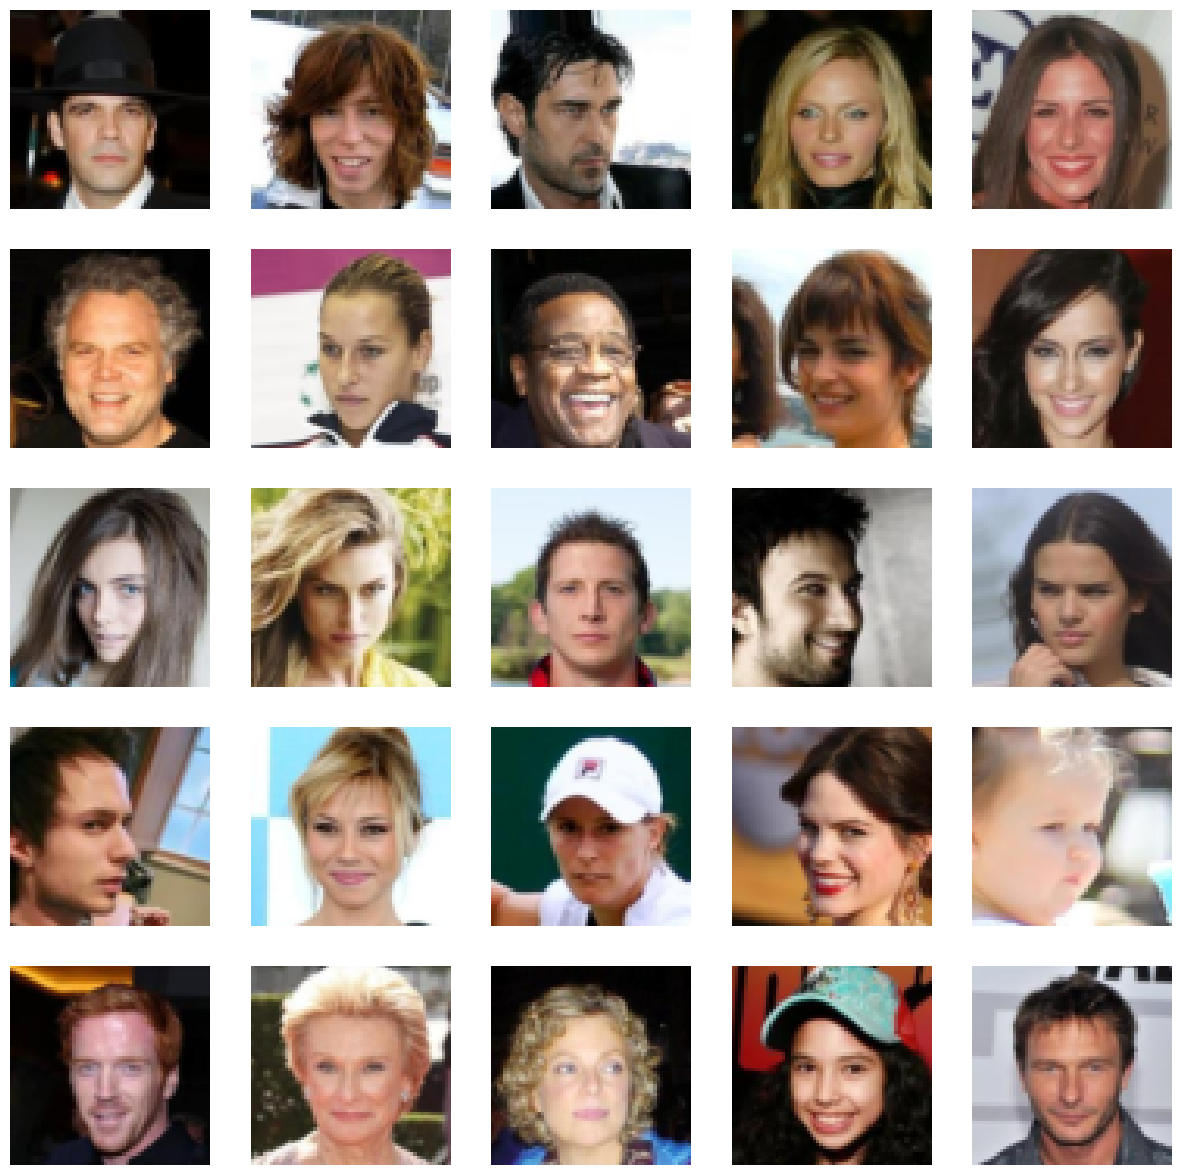

In [5]:
plt.figure(figsize=(15, 15))
for i in range(25):
    random_idx = np.random.randint(len(dataset))
    img = dataset[random_idx]
    plt.subplot(5, 5, i + 1)
    plot_img(img, t_invnormalize)
plt.show()

### Задача 1 (4/10 баллов): Построение и обучение нормального потока (Normalizing Flow) на CelebA

Необходимо обучить нормальный поток до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). 

Измерьте FID и Negative Log Likelihood для оценки модели.

Внутри потока можно использовать любые компоненты: Coupling/Autoregressive/Linear слои, произвольные трансформации и т.д. Главное — реализовать их самостоятельно без копипаста.

Можно использовать как сверточные потоки (обычно дают лучшие результаты, но сложнее реализуются), так и линейные потоки (будут менее качественными), при этом можно предварительно свести изображение к вектору.

Можно использовать готовый код из репозитория курса, но рекомендуется написать свою реализацию.

In [6]:
import torch.nn as nn


#### CNN слои


simple cnn

In [8]:
# Define CNN-based s and t networks
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

resnet-like cnn

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F



class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.relu(x + self.net(x))

class ScaleResNet(nn.Module):
    """ResNet for scale transformation in coupling layer"""
    def __init__(self, in_channels=3, hidden_channels=64, num_blocks=4):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True)
        ]
        for _ in range(num_blocks):
            layers.append(ResidualBlock(hidden_channels))
        layers.extend([
            nn.Conv2d(hidden_channels, in_channels, 3, padding=1),
            nn.Tanh()  # Constrain scale outputs
        ])
        self.net = nn.Sequential(*layers)
        
        # Zero-initialize final convolution
        self.net[-2].weight.data.zero_()
        self.net[-2].bias.data.zero_()

    def forward(self, x):
        return self.net(x)

class TransResNet(nn.Module):
    """ResNet for translation transformation in coupling layer"""
    def __init__(self, in_channels=3, hidden_channels=64, num_blocks=4):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True)
        ]
        for _ in range(num_blocks):
            layers.append(ResidualBlock(hidden_channels))
        layers.append(nn.Conv2d(hidden_channels, in_channels, 3, padding=1))
        self.net = nn.Sequential(*layers)
        
        # Zero-initialize final convolution
        self.net[-1].weight.data.zero_()
        self.net[-1].bias.data.zero_()

    def forward(self, x):
        return self.net(x)





#### RealNVP

In [ ]:
from torch import nn

class MLP(nn.Module):

    def __init__(self, nin, nout, nh):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nin, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nout),
        )
    def forward(self, x):
        return self.net(x)

class AffineConstantFlow(nn.Module):

    def __init__(self, dim: int, scale: bool = True, shift: bool = True):
        super().__init__()
        # Initialize scaling parameter if enabled; otherwise, set to None.
        self.s = nn.Parameter(torch.randn(1, dim)) if scale else None
        # Initialize shifting parameter if enabled; otherwise, set to None.
        self.t = nn.Parameter(torch.randn(1, dim)) if shift else None
        
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:

        # Use provided parameters or default to zeros if not enabled.
        s = self.s if self.s is not None else torch.zeros_like(x)
        t = self.t if self.t is not None else torch.zeros_like(x)
        # Apply the affine transformation.
        z = x * torch.exp(s) + t
        # Compute log-determinant: sum over dimensions.
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def inverse(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:

        s = self.s if self.s is not None else torch.zeros_like(z)
        t = self.t if self.t is not None else torch.zeros_like(z)
        # Reverse the affine transformation.
        x = (z - t) * torch.exp(-s)
        # Log-determinant for the inverse transformation.
        log_det = torch.sum(-s, dim=1)
        return x, log_det


class ActNorm(AffineConstantFlow):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Flag to check if data-dependent initialization is completed.
        self.data_dep_init_done = False
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:

        if not self.data_dep_init_done:
            # Ensure both scale and shift are available for initialization.
            assert self.s is not None and self.t is not None, "ActNorm requires both scale and shift."
            # Initialize scaling parameter based on the inverse of the standard deviation.
            self.s.data = (-torch.log(x.std(dim=0, keepdim=True))).detach()
            # Initialize shifting parameter so that the mean becomes zero after scaling.
            self.t.data = (-(x * torch.exp(self.s)).mean(dim=0, keepdim=True)).detach()
            self.data_dep_init_done = True
        # Call the parent's forward method.
        return super().forward(x)



class AffineHalfFlow(nn.Module):

    def __init__(self, dim: int, parity: bool, net_class=MLP, nh: int = 24, scale: bool = True, shift: bool = True):
        super().__init__()
        self.dim = dim
        self.parity = parity
        # Split input dimensions into two parts; if odd, the second part is larger.
        self.n1 = dim // 2
        self.n2 = dim - self.n1
        # Initialize the network to compute scaling if enabled; else return zeros.
        if scale:
            self.s_cond = net_class(self.n1, self.n2, nh)
        else:
            self.s_cond = lambda x: torch.zeros(x.size(0), self.n2, device=x.device, dtype=x.dtype)
        # Initialize the network to compute shifting if enabled; else return zeros.
        if shift:
            self.t_cond = net_class(self.n1, self.n2, nh)
        else:
            self.t_cond = lambda x: torch.zeros(x.size(0), self.n2, device=x.device, dtype=x.dtype)
        
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:

        if not self.parity:
            # Standard order: first half conditions the second half.
            x_a = x[:, :self.n1]
            x_b = x[:, self.n1:]
        else:
            # Swap roles: latter part conditions the first part.
            x_a = x[:, self.n2:]
            x_b = x[:, :self.n2]
        # Compute scale and shift using the conditioning network.
        s = self.s_cond(x_a)
        t = self.t_cond(x_a)
        # Apply the affine transformation to the target half.
        z_b = x_b * torch.exp(s) + t
        # Reassemble the output to preserve the original order.
        if not self.parity:
            z = torch.cat([x_a, z_b], dim=1)
        else:
            z = torch.cat([z_b, x_a], dim=1)
        # Sum over the scale parameters to get the log-determinant.
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def inverse(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:

        if not self.parity:
            z_a = z[:, :self.n1]
            z_b = z[:, self.n1:]
        else:
            z_a = z[:, self.n2:]
            z_b = z[:, :self.n2]
        # Recompute the scale and shift parameters from the conditioning part.
        s = self.s_cond(z_a)
        t = self.t_cond(z_a)
        # Invert the affine transformation.
        x_b = (z_b - t) * torch.exp(-s)
        if not self.parity:
            x = torch.cat([z_a, x_b], dim=1)
        else:
            x = torch.cat([x_b, z_a], dim=1)
        # Inverse log-determinant is the negative sum of scales.
        log_det = torch.sum(-s, dim=1)
        return x, log_det

# ------------------------------------------------------------------------

class NormalizingFlow(nn.Module):

    def __init__(self, flows):
        super().__init__()
        # Store flows in a ModuleList for proper registration.
        self.flows = nn.ModuleList(flows)

    def forward(self, x: torch.Tensor) -> tuple[list, torch.Tensor]:

        m, _ = x.shape
        # Initialize total log-determinant.
        log_det = torch.zeros(m, device=x.device, dtype=x.dtype)
        # Store the input as the first element.
        zs = [x]
        # Apply each flow sequentially.
        for flow in self.flows:
            x, ld = flow.forward(x)
            log_det += ld
            zs.append(x)
        return zs, log_det

    def inverse(self, z: torch.Tensor) -> tuple[list, torch.Tensor]:

        m, _ = z.shape
        log_det = torch.zeros(m, device=z.device, dtype=z.dtype)
        xs = [z]
        # Reverse the flow order for inversion.
        for flow in self.flows[::-1]:
            z, ld = flow.inverse(z)
            log_det += ld
            xs.append(z)
        return xs, log_det


class NormalizingFlowModel(nn.Module):

    def __init__(self, prior, flows):
        super().__init__()
        self.prior = prior
        self.flow = NormalizingFlow(flows)
    
    def forward(self, x: torch.Tensor) -> tuple[list, torch.Tensor, torch.Tensor]:

        zs, log_det = self.flow.forward(x)
        # Compute log-probability under the prior for the final transformed variable.
        prior_logprob = self.prior.log_prob(zs[-1]).view(x.size(0), -1).sum(1)
        return zs, prior_logprob, log_det

    def inverse(self, z: torch.Tensor) -> tuple[list, torch.Tensor]:

        xs, log_det = self.flow.inverse(z)
        return xs, log_det
    
    def sample(self, num_samples: int) -> list:

        # Sample from the prior distribution.
        z = self.prior.sample((num_samples,))
        # Invert the flow to obtain data samples.
        xs, _ = self.flow.inverse(z)
        return xs


In [8]:
from munch import Munch

flow_conf = Munch()

flow_conf.batch_size = 1024
flow_conf.dim = 3 * 64 * 64
flow_conf.nh = 512

flow_conf.flows_count = 24

flow_conf.save_every = 10


In [9]:
import itertools

def add_act_norms(flows, dim):
    norms = [ActNorm(dim=dim) for _ in flows]
    flows = list(itertools.chain(*zip(norms, flows)))

In [10]:

from torch.distributions import MultivariateNormal

flows = [AffineHalfFlow(dim=flow_conf.dim, parity=i%2, nh=flow_conf.nh) for i in range(flow_conf.flows_count)]

add_act_norms(flows, flow_conf.dim)

prior = MultivariateNormal(torch.zeros(flow_conf.dim).to(device=device), 
                           torch.eye(flow_conf.dim).to(device=device))

model = NormalizingFlowModel(prior, flows).to(device)

In [11]:
def flatten_images(images):
    # images shape: (batch, 3, 64, 64)
    return images.view(images.size(0), -1)

In [16]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=flow_conf.batch_size,
    num_workers=8,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch.optim as optim


def train_nf(n_epoches, model):
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    print("number of params: ", sum(p.numel() for p in model.parameters()))
    
    model.train()
    train_losses = []  # To store average loss per epoch


    for epoch in range(n_epoches):
        model.train()
        epoch_loss = 0.0  # Track cumulative loss for the epoch
        batch_count = 0
        
        for step, batch in enumerate(dataloader):
            # Forward pass
            zs, prior_logprob, log_det = model(flatten_images(batch).to(device))
            logprob = prior_logprob + log_det
            loss = -torch.sum(logprob)  # NLL
            
            # Backward pass and optimize
            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            # Accumulate loss
            epoch_loss += loss.item()
            batch_count += 1

        # Calculate average epoch loss
        avg_epoch_loss = epoch_loss / batch_count
        train_losses.append(avg_epoch_loss)

        #### Visualization section ####
        model.eval()
        num_samples = 10
        samples = model.sample(num_samples)[-1].view(num_samples, 3, 64, 64)
        
        clear_output()
        
        # Create a figure with two subplots
        plt.figure(figsize=(15, 15))
        
        for i in range(num_samples):
            img = samples[i].detach().cpu()
            plt.subplot(5, 5, i + 1)
            plot_img(img, t_invnormalize)
            plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

        plt.plot(train_losses, label='Training Loss', linewidth=2)
        plt.scatter(range(len(train_losses)), train_losses, c='red')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.grid(True)
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
        ###############################

        if epoch % flow_conf.save_every == 0 and epoch > 0:
            torch.save(model.state_dict(), f"./checkpoints/nf_512_24_{epoch}.pth")
            
        print(f'Epoch: {epoch}, Loss: {avg_epoch_loss:.2f}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.65279996..1.7299446].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85392..1.8920704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.170038..3.3400583].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3013188..2.1494277].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8228663..2.5322795].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6750884..2.2797012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92947304..2.283257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7230693..2.1417298].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.66975343..1.3249469].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.73367

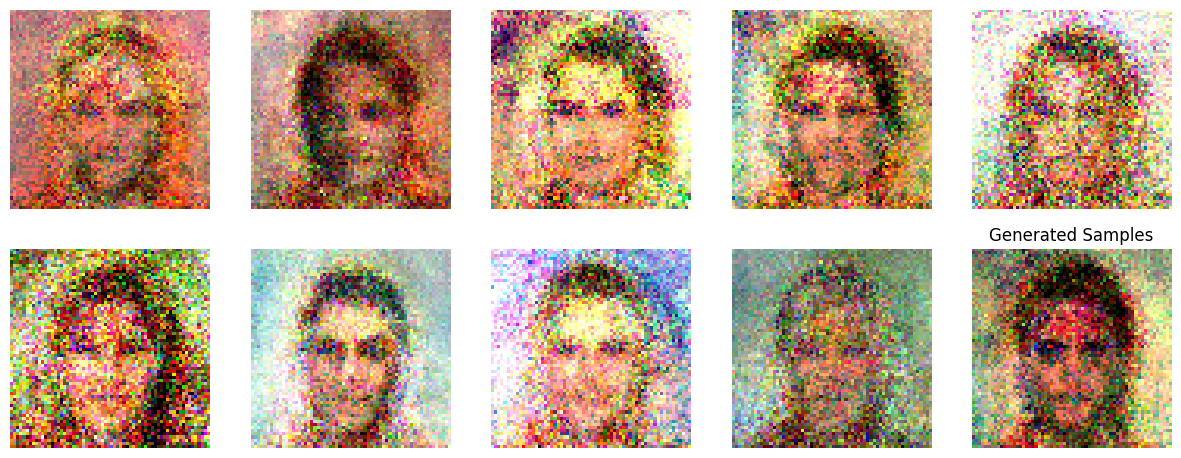

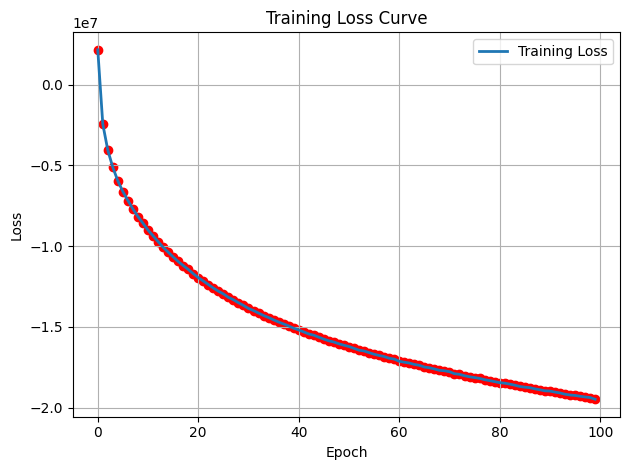

Epoch: 99, Loss: -19481344.49


In [ ]:
# train_nf(100, model)

In [ ]:
# torch.save(model.state_dict(), f"./checkpoints/nf_512_24_last.pth")

In [ ]:
model.load_state_dict(torch.load("./checkpoints/nf_512_24_last.pth"))

<All keys matched successfully>

In [33]:
model = model.to(device)

In [34]:
from utils import FidScore

@torch.no_grad()
def compute_nf_fid(nf: NormalizingFlowModel, num_samples=1000):
    nf.eval()
    real_images = torch.stack([dataset[i] for i in range(num_samples)], dim=0).to(device)

    reconstructions, _, _ = nf(flatten_images(real_images))
    reconstructions = reconstructions[-1].view(num_samples, 3, 64, 64)

    fid = FidScore()
    fid(real_images, reconstructions)
    return fid.compute()

In [ ]:
fid = compute_nf_fid(model, 10000)
fid

// 11000